## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence

In [3]:
file_path = '../Maxim-data/Distributions_fa_tau_dec.dat'  # Set the correct file path
parameterDependence = ParametersAxionMassDependence("taon_decay", file_path)

## Checking First Interpolation
In this step, we retrieve input data for different distributions and their interpolations (`f(q)`, `f(q) * q^1`, `f(q) * q^2`, `f(q) * q^3`). The goal is to compare raw input values with their interpolated results. It is crucial to mention that the true input data comes from the distribution `f(q) * q^2`, which originates from the Maxim code. This code calculates the real axion distribution in a specific production process, where axions are produced via taon decays:

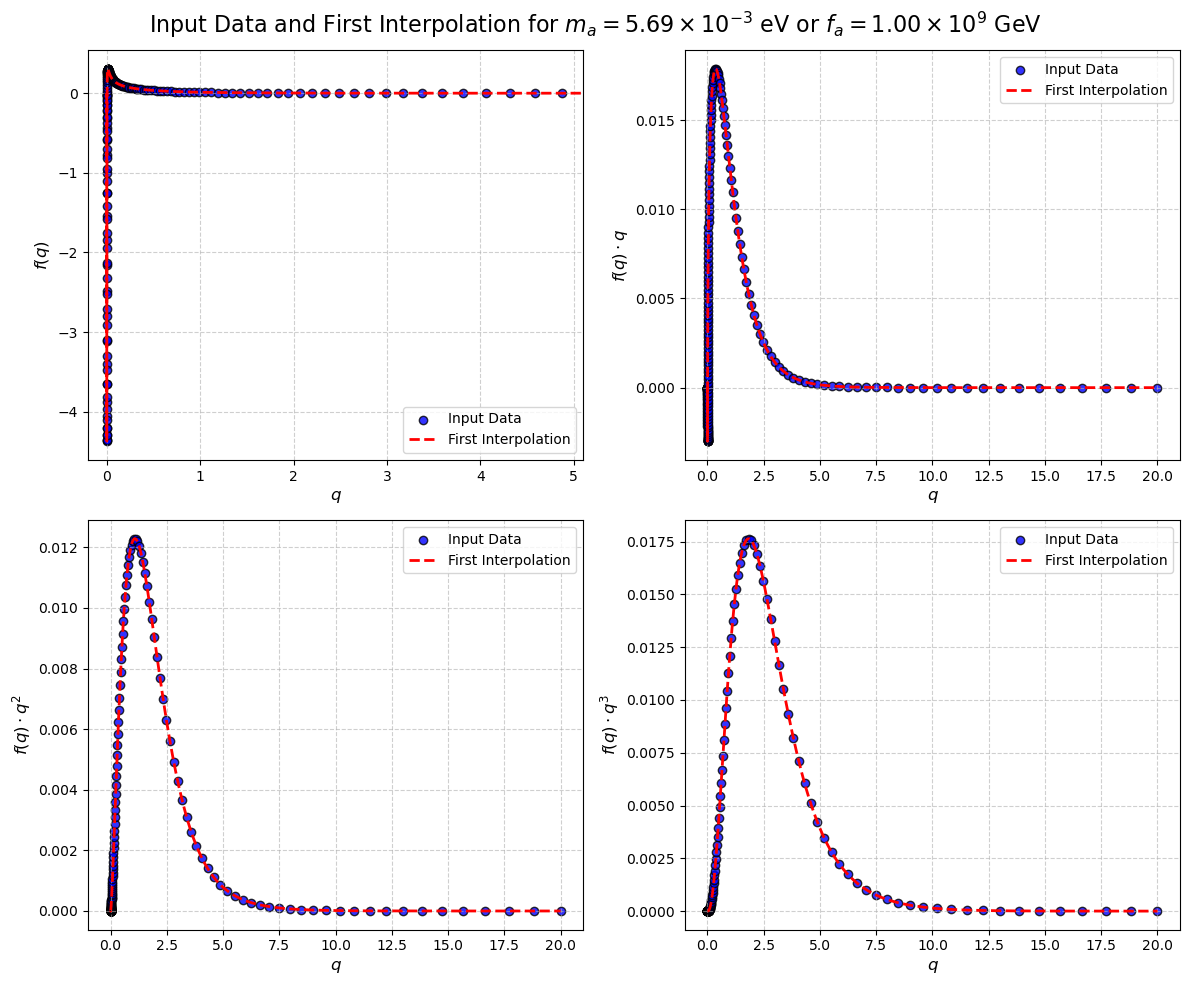

In [4]:
# Retrieve data
index = 299
axion_mass = parameterDependence.get_axion_masses()[index]
decay_constant = parameterDependence.calculate_fa(axion_mass)
input_dist_q0 = parameterDependence.get_input_distribution(dist="f(q)")
input_dist_q1 = parameterDependence.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = parameterDependence.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = parameterDependence.get_input_distribution(dist="f(q)_q3")
input_q_arr = parameterDependence.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# First interpolation data
interp1_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
interp1_dist_q0 = parameterDependence.get_interpolated_distribution(dist="f(q)")
interp1_dist_q1 = parameterDependence.get_interpolated_distribution(dist="f(q)_q1")
interp1_dist_q2 = parameterDependence.get_interpolated_distribution(dist="f(q)_q2")
interp1_dist_q3 = parameterDependence.get_interpolated_distribution(dist="f(q)_q3")

# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and First Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp_dists = [interp1_dist_q0, interp1_dist_q1, interp1_dist_q2, interp1_dist_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='First Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()

## Checking Parameter Axion Mass Dependence: $A(\log(m_{a}))$, $b(\log(m_{a}))$, $\mu(\log(m_{a}))$

In [5]:
# --- DISTRIBUTION: f(q)*q^2 ---
distribution = "f(q)_q2"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -5.30  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# --- polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# --- function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [-5.26011517e-07 -1.08512129e-05 -8.19593243e-05 -2.34857772e-04
  1.35636050e-04  1.96047177e-03  1.85303673e-03 -5.22561551e-03
 -6.48428819e-03  6.66247147e-03  1.33019291e-03  1.96029611e-02
 -2.58413487e-02  8.86955338e-01]
Polynomial fit coefficients for b: [-1.43731365e-06 -2.56856619e-05 -1.49927812e-04 -1.59807821e-04
  1.36117512e-03  3.39266408e-03 -4.25678086e-03 -1.55813760e-02
  7.26581623e-03  2.86365779e-02 -2.26668323e-02  4.43921246e-02
  6.40904636e-02 -8.73872330e-01]
Polynomial fit coefficients for μ: [-3.09985162e-06 -5.70195516e-05 -3.42085093e-04 -3.83645090e-04
  3.25231513e-03  8.34912879e-03 -1.13999197e-02 -4.12152141e-02
  2.72400780e-02  7.98604075e-02 -1.12070110e-01  1.75533235e-01
  5.97991132e-01 -5.37523370e+00]


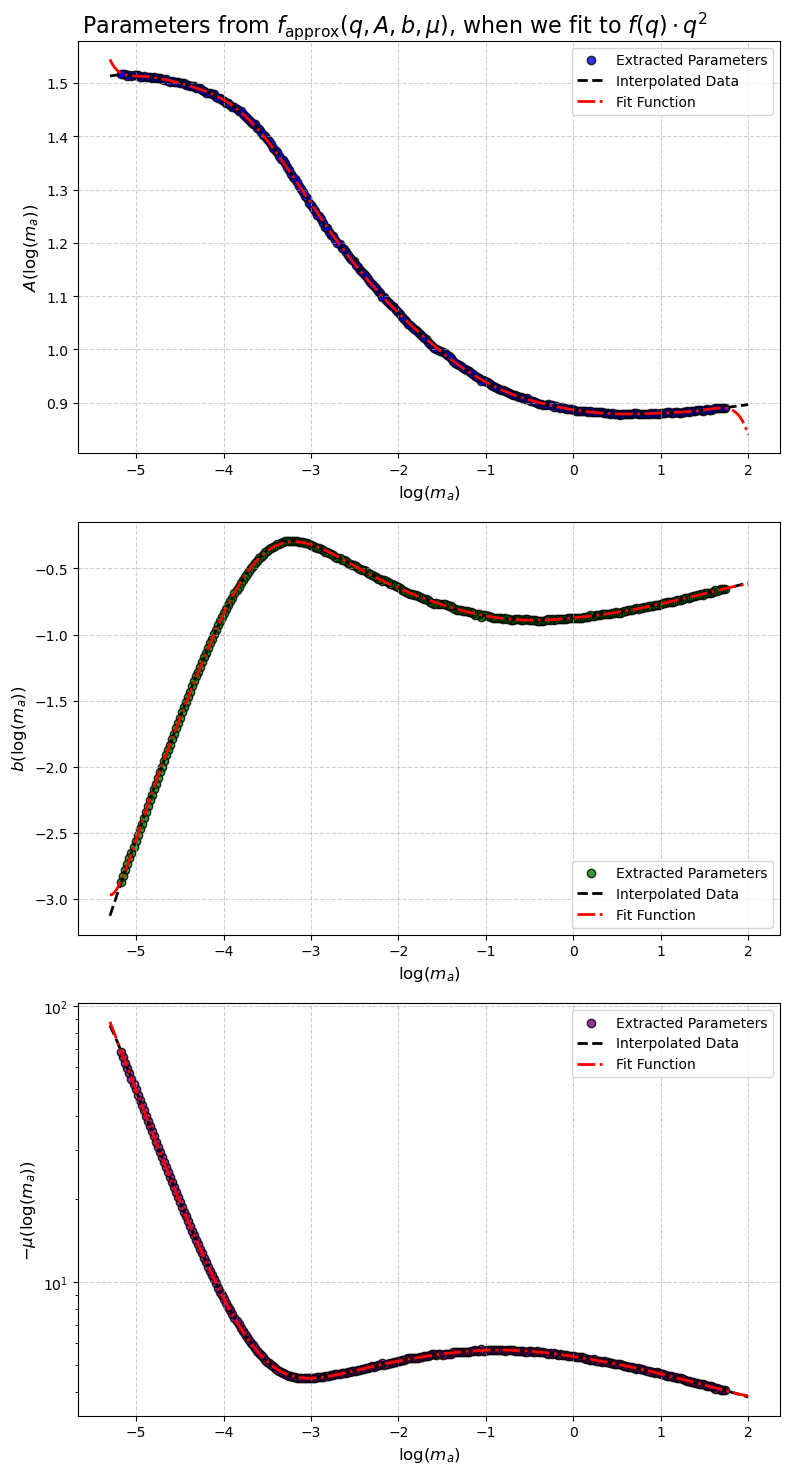

In [6]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^2$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Checking Second Interpolation

In [7]:
# --- Change base function, which we use to find A, b and mu mass dependence
parameterDependence.switch_fitting_function("A", "test_polynomial")
parameterDependence.switch_fitting_function("b", "test_polynomial")
parameterDependence.switch_fitting_function("mu", "test_polynomial")

Switched A fitting function to stored fit 'test_polynomial'.
Switched b fitting function to stored fit 'test_polynomial'.
Switched mu fitting function to stored fit 'test_polynomial'.


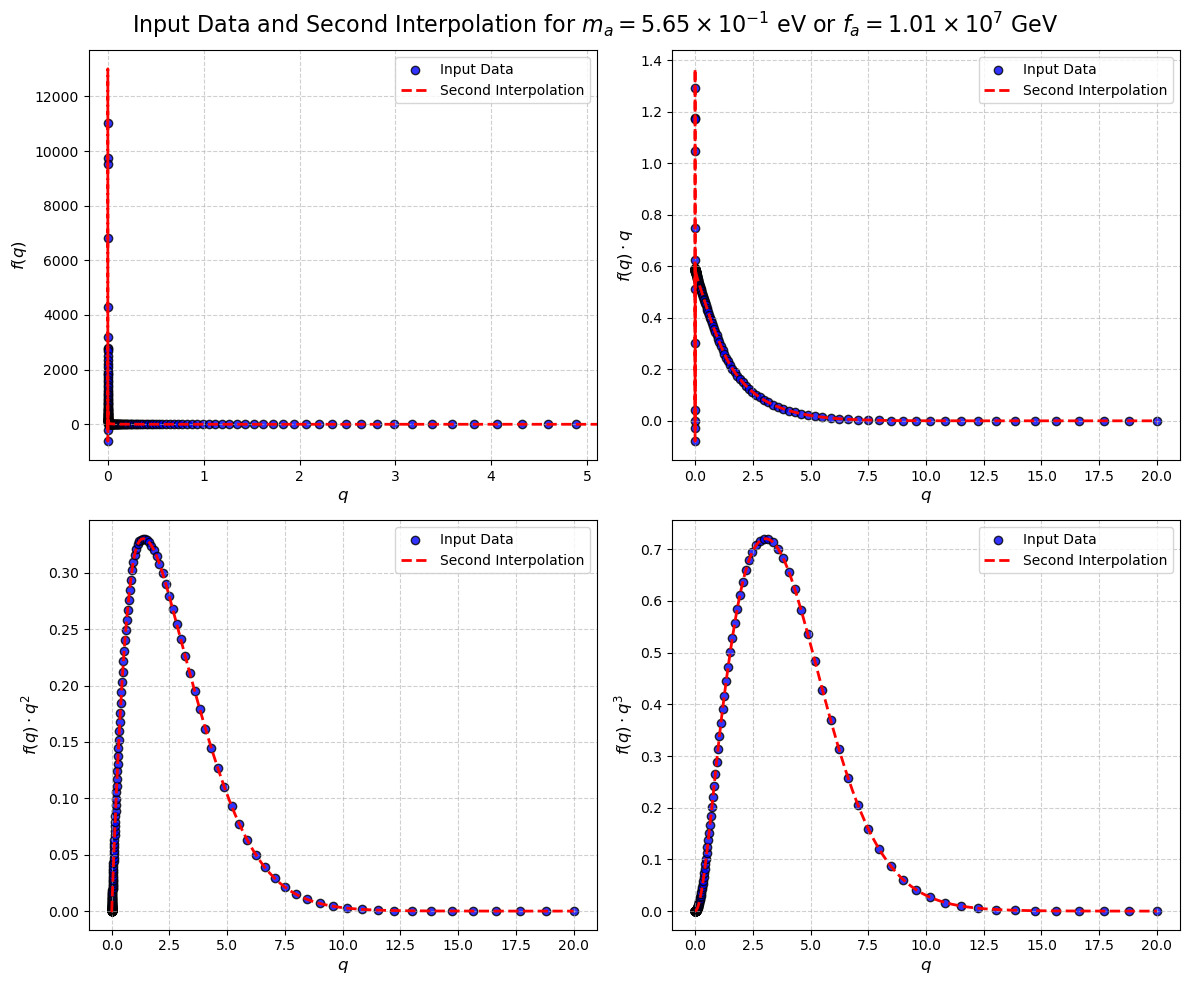

In [8]:
# Retrieve data
index = 100
axion_mass = parameterDependence.get_axion_masses()[index]
decay_constant = parameterDependence.calculate_fa(axion_mass)
input_dist_q0 = parameterDependence.get_input_distribution(dist="f(q)")
input_dist_q1 = parameterDependence.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = parameterDependence.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = parameterDependence.get_input_distribution(dist="f(q)_q3")
input_q_arr = parameterDependence.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# --- SECOND INTERPOLATION
interp2_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
second_interpolation_q3 = parameterDependence.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q3")
second_interpolation_q2 = parameterDependence.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q2")
second_interpolation_q1 = parameterDependence.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q1")
second_interpolation_q0 = parameterDependence.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)")

# --- PLOT PART
# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and Second Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp2_dists = [second_interpolation_q0, second_interpolation_q1, second_interpolation_q2, second_interpolation_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='Second Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()